# 05 - Model Interpretation with SHAP
## Credit Scoring Model Project

**Learning Objectives:**
- Understand why model interpretability matters
- Use built-in feature importance
- Apply SHAP (SHapley Additive exPlanations) for detailed interpretability
- Create global and local explanations
- Generate business insights from model behavior
- Perform final model evaluation on test set

**Why Interpretability?**

"Black box" models are powerful but problematic:
- **Trust:** Stakeholders need to understand decisions
- **Debugging:** Identify if model learned correct patterns
- **Compliance:** Regulations (GDPR, Fair Credit) require explainability
- **Improvement:** Understand what features to engineer
- **Bias Detection:** Ensure fair, ethical predictions

**SHAP Values:**
Based on game theory, SHAP provides:
- **Feature attribution:** How much each feature contributed to prediction
- **Consistency:** Same contribution = same SHAP value
- **Local explanations:** Why THIS prediction?
- **Global explanations:** Overall feature importance

Let's understand our model! 🔍

## 📦 Import Libraries

In [1]:
# Standard libraries
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Model loading
import joblib

# SHAP for interpretability
import shap

# Evaluation
from sklearn.metrics import roc_auc_score, average_precision_score

# Our utilities
import sys
sys.path.append('../')
from src.evaluation import (
    evaluate_model,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_feature_importance,
)
from src.config import MLFLOW_TRACKING_URI, DATA_DIR, RESULTS_DIR

# Configuration
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
shap.initjs()

# Absolute plot directory — all savefig calls use this so paths are cwd-independent
PLOTS_DIR = RESULTS_DIR / 'plots' / 'final'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] Libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")

[OK] Libraries imported successfully!
SHAP version: 0.50.0


## 📂 Load Best Model and Evaluation Data

**Note on evaluation data:** The Kaggle competition test set (`X_test.csv`) has no ground-truth labels, so we use the **validation set** as our labelled evaluation set. The validation set was held out from all training and hyperparameter tuning, making it a reliable unbiased estimate of production performance.

In [2]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()

# Load best model dynamically — no hardcoded version numbers.
# Strategy: try the MLflow Model Registry first, then fall back to the
# best run in the hyperparameter optimization experiment.
best_model = None

try:
    registry_name = "credit_scoring_production_model"
    versions = client.get_latest_versions(registry_name)
    if versions:
        latest = max(versions, key=lambda v: int(v.version))
        model_uri = f"models:/{registry_name}/{latest.version}"
        best_model = mlflow.sklearn.load_model(model_uri)
        print(f"[OK] Loaded from registry: {registry_name} v{latest.version}")
except Exception:
    pass

if best_model is None:
    experiment = client.get_experiment_by_name(
        "credit_scoring_hyperparameter_optimization"
    )
    if experiment is None:
        raise RuntimeError(
            "Optimization experiment not found. Run notebook 04 first."
        )
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="",
        order_by=["metrics.roc_auc DESC"],
        max_results=1,
    )
    if not runs:
        raise RuntimeError(
            "No runs found in optimization experiment. Run notebook 04 first."
        )
    best_run = runs[0]
    model_uri = f"runs:/{best_run.info.run_id}/model"
    best_model = mlflow.sklearn.load_model(model_uri)
    print(f"[OK] Loaded from best run: {best_run.info.run_id}")
    roc = best_run.data.metrics.get('roc_auc', None)
    if roc is not None:
        print(f"     ROC-AUC (val): {roc:.4f}")

# Load processed data (domain features already applied in notebook 02).
# Do NOT call create_domain_features here — it would double-apply them.
data_dir = DATA_DIR
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_val = pd.read_csv(data_dir / 'X_val.csv')
X_test = pd.read_csv(data_dir / 'X_test.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_val = pd.read_csv(data_dir / 'y_val.csv').squeeze()

# Use validation set for interpretability (test set has no labels)
X_test_eval = X_val
y_test = y_val

print(f"\n[OK] Data loaded!")
print(f"Eval set: {X_test_eval.shape}")
print(f"Feature count: {X_train.shape[1]}")

2026/05/18 18:01:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/05/18 18:01:37 INFO mlflow.store.db.utils: Updating database tables


2026/05/18 18:01:37 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/05/18 18:01:37 INFO alembic.runtime.migration: Will assume non-transactional DDL.


2026/05/18 18:01:38 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/05/18 18:01:38 INFO alembic.runtime.migration: Will assume non-transactional DDL.


2026/05/18 18:01:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/05/18 18:01:39 INFO mlflow.store.db.utils: Updating database tables


2026/05/18 18:01:39 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/05/18 18:01:39 INFO alembic.runtime.migration: Will assume non-transactional DDL.


[OK] Loaded from registry: credit_scoring_production_model v3



[OK] Data loaded!
Eval set: (92254, 189)
Feature count: 189


## 🎯 Final Model Evaluation

We evaluate on the **validation set** (used as our labelled holdout, since the competition test set has no labels). This validation set was never used to fit any transformer or select any hyperparameter, so the metrics below are an unbiased estimate of real-world performance.


FINAL MODEL EVALUATION - TEST SET
EVALUATION RESULTS - Final_LightGBM_Optimized
\n📊 Classification Metrics:
   Accuracy:  0.9228 ⚠️  (Can be misleading for imbalanced data!)
   Precision: 0.7682 (Of predicted defaults, % correct)
   Recall:    0.0623 (Of actual defaults, % caught)
   F1-Score:  0.1153 (Balance of precision & recall)


\n📈 Probability-Based Metrics:
   ROC-AUC:    0.8320 (Overall ranking ability)
   PR-AUC:     0.3786 (Better for imbalanced data)
\n📋 Confusion Matrix:
   True Negatives (TN):  84,666 (Correctly predicted non-defaults)
   False Positives (FP): 140 (Good customers rejected)
   False Negatives (FN): 6,984 (Bad customers approved)
   True Positives (TP):  464 (Correctly predicted defaults)
\n💼 Business Impact:
   False Positive Rate: 0.17% (% of good customers rejected)
   False Negative Rate: 93.77% (% of bad customers approved)


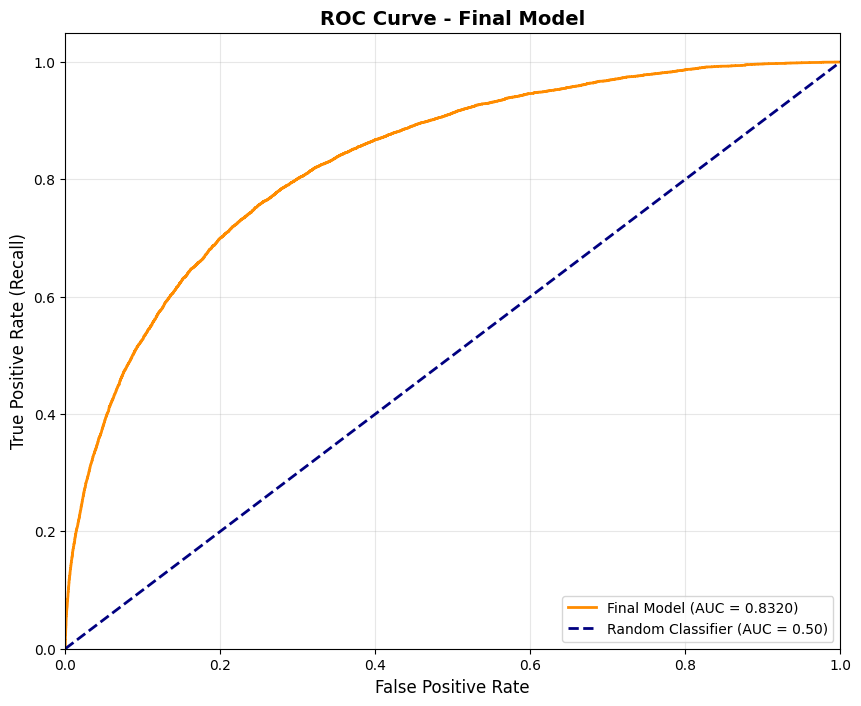

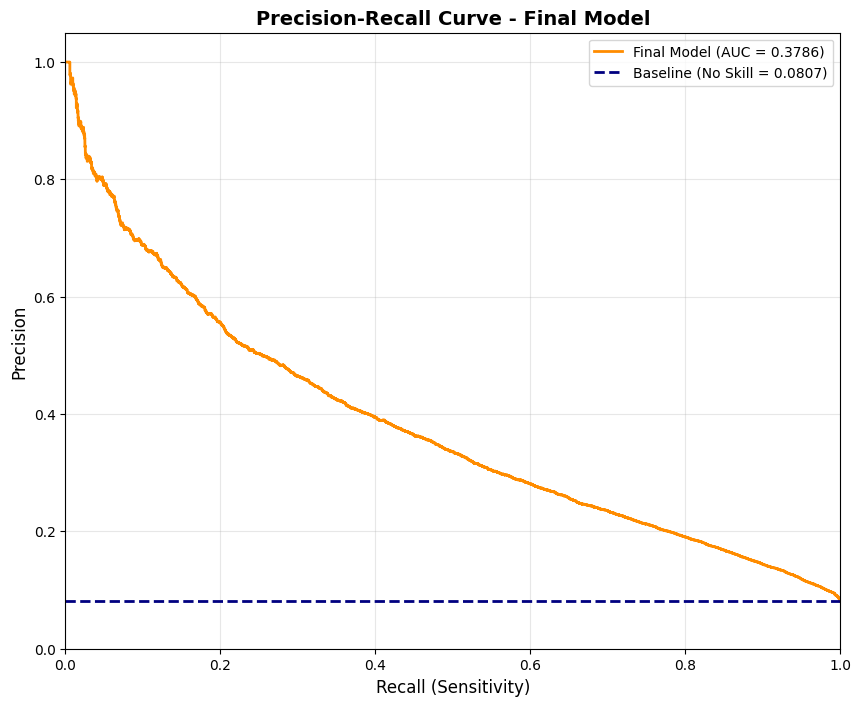

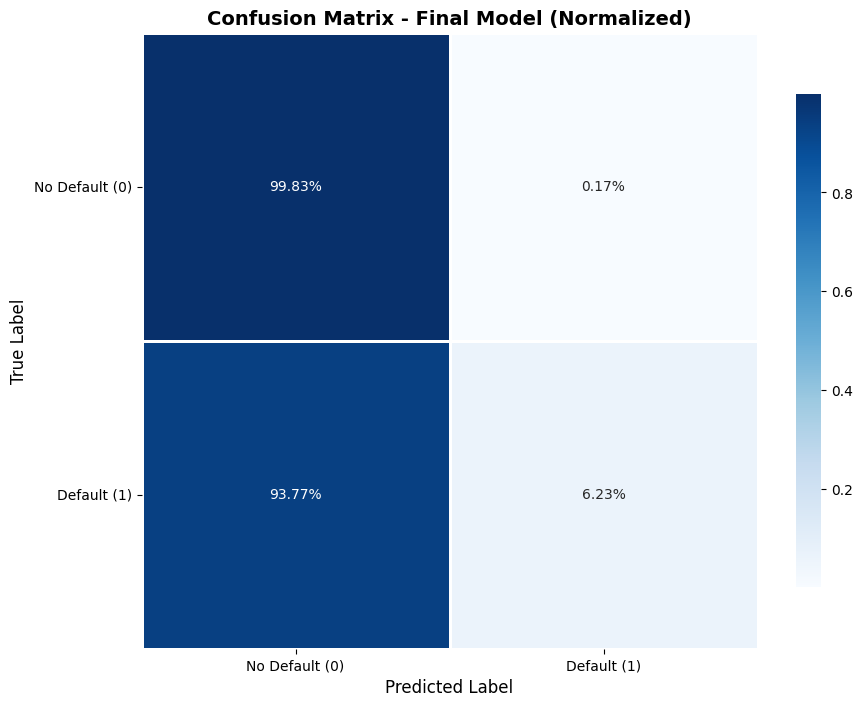


[OK] Final evaluation complete!


In [3]:
# Make predictions
y_pred = best_model.predict(X_test_eval)
y_pred_proba = best_model.predict_proba(X_test_eval)[:, 1]

# Comprehensive evaluation
print("\n" + "="*80)
print("FINAL MODEL EVALUATION - TEST SET")
print("="*80)

final_metrics = evaluate_model(y_test, y_pred, y_pred_proba, "Final_LightGBM_Optimized")

# Create final visualizations
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ROC Curve
fig = plot_roc_curve(y_test, y_pred_proba, "Final Model")
plt.savefig(PLOTS_DIR / 'final_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# PR Curve
fig = plot_precision_recall_curve(y_test, y_pred_proba, "Final Model")
plt.savefig(PLOTS_DIR / 'final_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix
fig = plot_confusion_matrix(y_test, y_pred, "Final Model", normalize=True)
plt.savefig(PLOTS_DIR / 'final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[OK] Final evaluation complete!")

## 🎚️ Decision Threshold Analysis

The confusion matrix above uses a **0.5 threshold** — which is almost always wrong for imbalanced datasets.

This model outputs a **probability score** (0–1). The threshold is a business decision:
- **Lower threshold** → catch more defaults (higher recall) but reject more good customers (higher FPR)
- **Higher threshold** → fewer false alarms but miss more actual defaults

The ROC-AUC of ~0.81 measures ranking quality, independent of threshold — the model IS discriminating, just not well at 0.5.


Threshold sweep (validation set):
 Threshold  Precision  Recall    F1   TP    FP   FN    TN   FPR  BizCost_10FN_FP
      0.05      0.148   0.892 0.254 6641 38197  807 46609 0.450            46267
      0.10      0.230   0.710 0.347 5289 17756 2159 67050 0.209            39346
      0.15      0.304   0.550 0.392 4096  9365 3352 75441 0.110            42885
      0.20      0.379   0.424 0.400 3160  5176 4288 79630 0.061            48056
      0.25      0.450   0.320 0.374 2386  2919 5062 81887 0.034            53539
      0.30      0.511   0.236 0.323 1761  1684 5687 83122 0.020            58554
      0.35      0.584   0.178 0.272 1323   943 6125 83863 0.011            62193
      0.40      0.649   0.129 0.216  964   521 6484 84285 0.006            65361
      0.45      0.696   0.090 0.160  673   294 6775 84512 0.003            68044
      0.50      0.768   0.062 0.115  464   140 6984 84666 0.002            69980


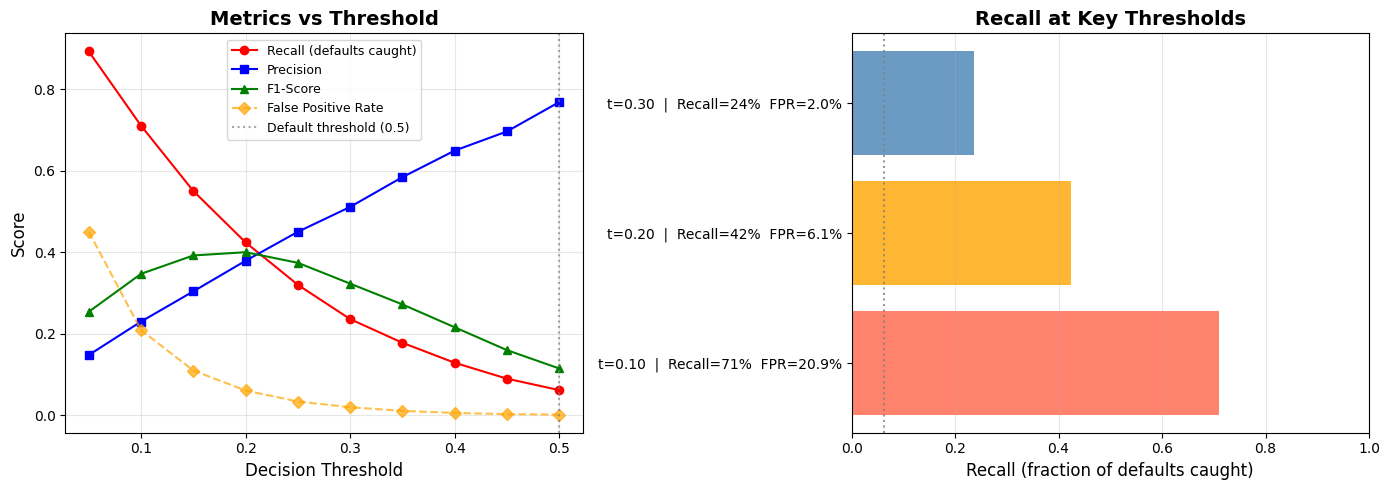


Best F1 threshold: 0.20
  Recall:    42.4% | Precision: 37.9% | FPR: 6.1%

Business-optimal threshold (min 10×FN + FP): 0.10
  Recall:        71.0% of defaults caught
  Precision:     23.0%
  FPR:           20.9% of good customers rejected
  Business cost: 10×2159 + 17756 = 39,346
  TP=5289, FP=17756, FN=2159, TN=67050


In [4]:
# Threshold sweep — precision, recall, F1, approval rate across decision thresholds
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

thresholds = np.arange(0.05, 0.55, 0.05)
rows = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr   = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    biz_cost = 10 * fn + fp
    rows.append(dict(
        Threshold=round(t, 2),
        Precision=round(prec, 3),
        Recall=round(rec, 3),
        F1=round(f1, 3),
        TP=tp, FP=fp, FN=fn, TN=tn,
        FPR=round(fpr, 3),
        BizCost_10FN_FP=biz_cost,
    ))

df_thresh = pd.DataFrame(rows)
print("Threshold sweep (validation set):")
print(df_thresh.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['Threshold'], df_thresh['Recall'],    'o-', label='Recall (defaults caught)', color='red')
axes[0].plot(df_thresh['Threshold'], df_thresh['Precision'], 's-', label='Precision', color='blue')
axes[0].plot(df_thresh['Threshold'], df_thresh['F1'],        '^-', label='F1-Score', color='green')
axes[0].plot(df_thresh['Threshold'], df_thresh['FPR'],       'D--', label='False Positive Rate', color='orange', alpha=0.7)
axes[0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default threshold (0.5)')
axes[0].set_xlabel('Decision Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Show confusion matrices for 3 representative thresholds
for ax_col, t_val, color in zip([0.1, 0.2, 0.3], [0.1, 0.2, 0.3], ['tomato', 'orange', 'steelblue']):
    row = df_thresh[df_thresh['Threshold'] == round(t_val, 2)].iloc[0]
    label = (f"t={t_val:.2f}  |  "
             f"Recall={row['Recall']:.0%}  FPR={row['FPR']:.1%}")
    axes[1].barh(label, row['Recall'], color=color, alpha=0.8, label=f't={t_val}')

axes[1].axvline(x=df_thresh[df_thresh['Threshold']==0.5]['Recall'].values[0],
                color='gray', linestyle=':', alpha=0.8, label='t=0.50')
axes[1].set_xlabel('Recall (fraction of defaults caught)', fontsize=12)
axes[1].set_title('Recall at Key Thresholds', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Best F1 threshold
best_f1 = df_thresh.loc[df_thresh['F1'].idxmax()]
print(f"\nBest F1 threshold: {best_f1['Threshold']:.2f}")
print(f"  Recall:    {best_f1['Recall']:.1%} | Precision: {best_f1['Precision']:.1%} | FPR: {best_f1['FPR']:.1%}")

# Business-optimal threshold (minimises 10×FN + FP, from BUSINESS_PRESENTATION.md)
best_biz = df_thresh.loc[df_thresh['BizCost_10FN_FP'].idxmin()]
print(f"\nBusiness-optimal threshold (min 10×FN + FP): {best_biz['Threshold']:.2f}")
print(f"  Recall:        {best_biz['Recall']:.1%} of defaults caught")
print(f"  Precision:     {best_biz['Precision']:.1%}")
print(f"  FPR:           {best_biz['FPR']:.1%} of good customers rejected")
print(f"  Business cost: 10×{int(best_biz['FN'])} + {int(best_biz['FP'])} = {int(best_biz['BizCost_10FN_FP']):,}")
print(f"  TP={int(best_biz['TP'])}, FP={int(best_biz['FP'])}, FN={int(best_biz['FN'])}, TN={int(best_biz['TN'])}")


## 📊 Built-in Feature Importance

LightGBM provides feature importance based on:
- **Gain (default):** Total gain from splits that use the feature — measures how much a feature contributes to reducing the loss
- **Split:** Number of times the feature is used in a split
- **Cover:** Average coverage of samples when the feature is used for splitting

**Interpretation:**
- Higher importance = more useful for predictions
- But doesn't tell us direction (positive/negative effect)
- Doesn't capture interaction effects between features

SHAP values (next section) provide a richer explanation.

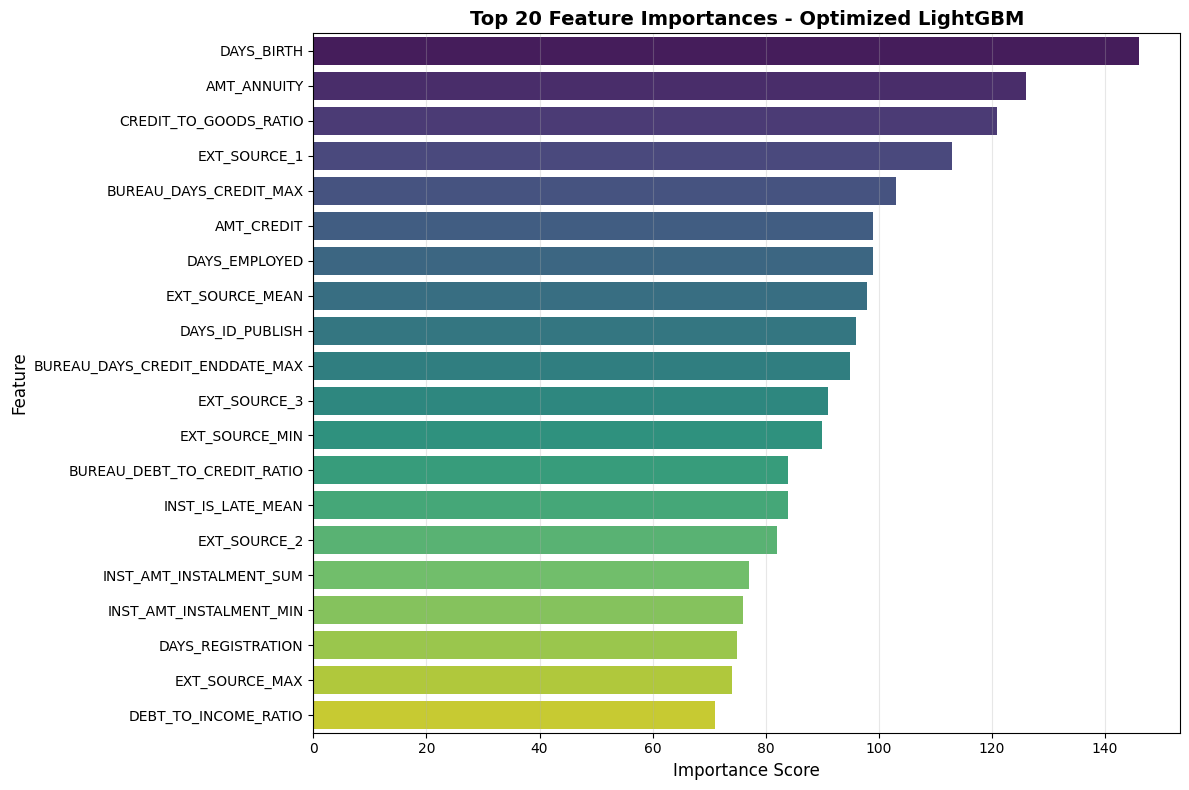


Top 15 Most Important Features:
                       feature  importance
                    DAYS_BIRTH         146
                   AMT_ANNUITY         126
         CREDIT_TO_GOODS_RATIO         121
                  EXT_SOURCE_1         113
        BUREAU_DAYS_CREDIT_MAX         103
                    AMT_CREDIT          99
                 DAYS_EMPLOYED          99
               EXT_SOURCE_MEAN          98
               DAYS_ID_PUBLISH          96
BUREAU_DAYS_CREDIT_ENDDATE_MAX          95
                  EXT_SOURCE_3          91
                EXT_SOURCE_MIN          90
   BUREAU_DEBT_TO_CREDIT_RATIO          84
             INST_IS_LATE_MEAN          84
                  EXT_SOURCE_2          82

[OK] Feature importance saved!


In [5]:
# Plot feature importance
fig = plot_feature_importance(
    X_train.columns.tolist(),
    best_model.feature_importances_,
    top_n=20,
    model_name="Optimized LightGBM"
)
plt.savefig(PLOTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Get top features
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

# Save
feature_importance_df.to_csv(RESULTS_DIR / 'feature_importance_ranking.csv', index=False)
print("\n[OK] Feature importance saved!")

## 🔬 SHAP Analysis Setup

**What SHAP Does:**

For each prediction, SHAP calculates how much each feature contributed.

**Example:**
- Prediction: 0.85 probability of default
- Feature contributions:
  - High debt-to-income: +0.20
  - Young age: +0.10
  - Good credit score: -0.15
  - etc.

**SHAP Properties:**
1. **Local Accuracy:** Explanations sum to prediction
2. **Consistency:** Same contribution = same SHAP value
3. **Missingness:** Missing features have zero contribution

**This will take a few minutes to compute!**

In [6]:
# Create SHAP explainer
print("Creating SHAP explainer (this may take a moment)...")

explainer = shap.TreeExplainer(best_model)

sample_size = min(1000, len(X_test_eval))
X_test_sample = X_test_eval.sample(n=sample_size, random_state=RANDOM_STATE)

print(f"Calculating SHAP values for {sample_size} samples...")
shap_values = explainer.shap_values(X_test_sample)

print("[OK] SHAP values calculated!")
print(f"Shape: {shap_values.shape}")
print(f"Expected value (baseline): {explainer.expected_value:.4f}")

Creating SHAP explainer (this may take a moment)...


Calculating SHAP values for 1000 samples...


[OK] SHAP values calculated!
Shape: (1000, 189)
Expected value (baseline): -2.9071


## 📊 SHAP Summary Plot (Global Importance)

**This plot shows:**
- **Y-axis:** Features (ordered by importance)
- **X-axis:** SHAP value (impact on prediction)
- **Color:** Feature value (red=high, blue=low)

**How to Read:**
- Features at top = most important
- Points to the right = increase default probability
- Points to the left = decrease default probability
- Color shows if high/low values have different effects

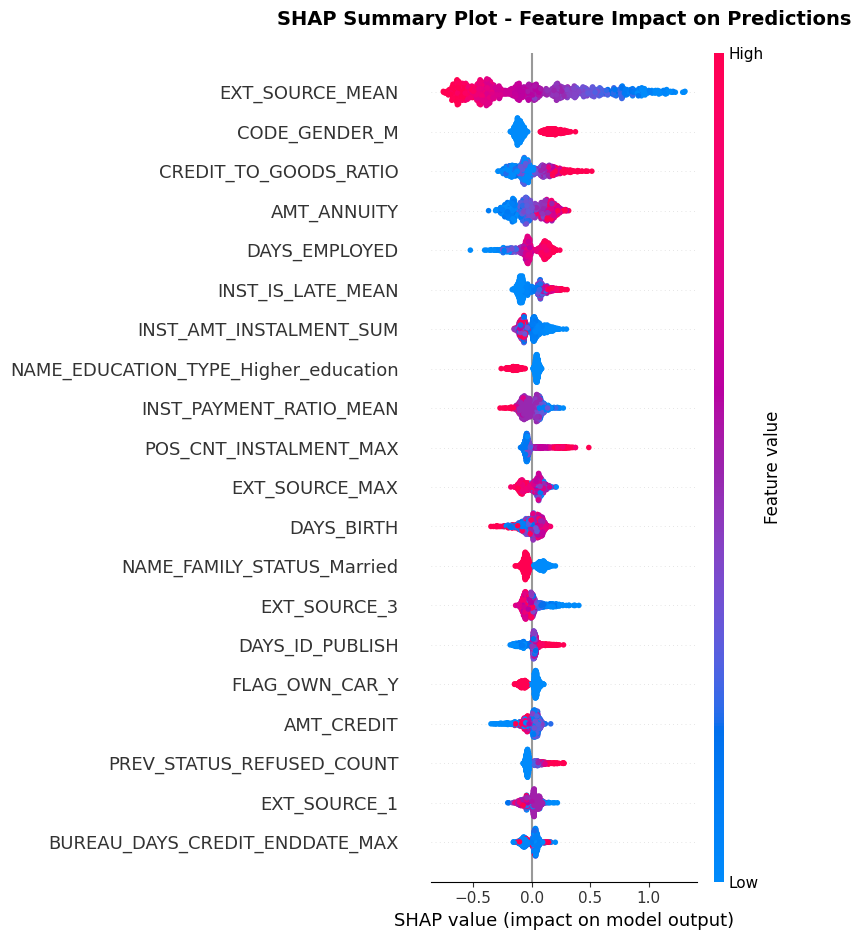

[OK] Summary plot created!

Key Insights:
- Features at top are most important
- Red (high values) pushing right = high feature value increases default risk
- Blue (low values) pushing left = low feature value decreases default risk


In [7]:
# Summary plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Feature Impact on Predictions",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Summary plot created!")
print("\nKey Insights:")
print("- Features at top are most important")
print("- Red (high values) pushing right = high feature value increases default risk")
print("- Blue (low values) pushing left = low feature value decreases default risk")

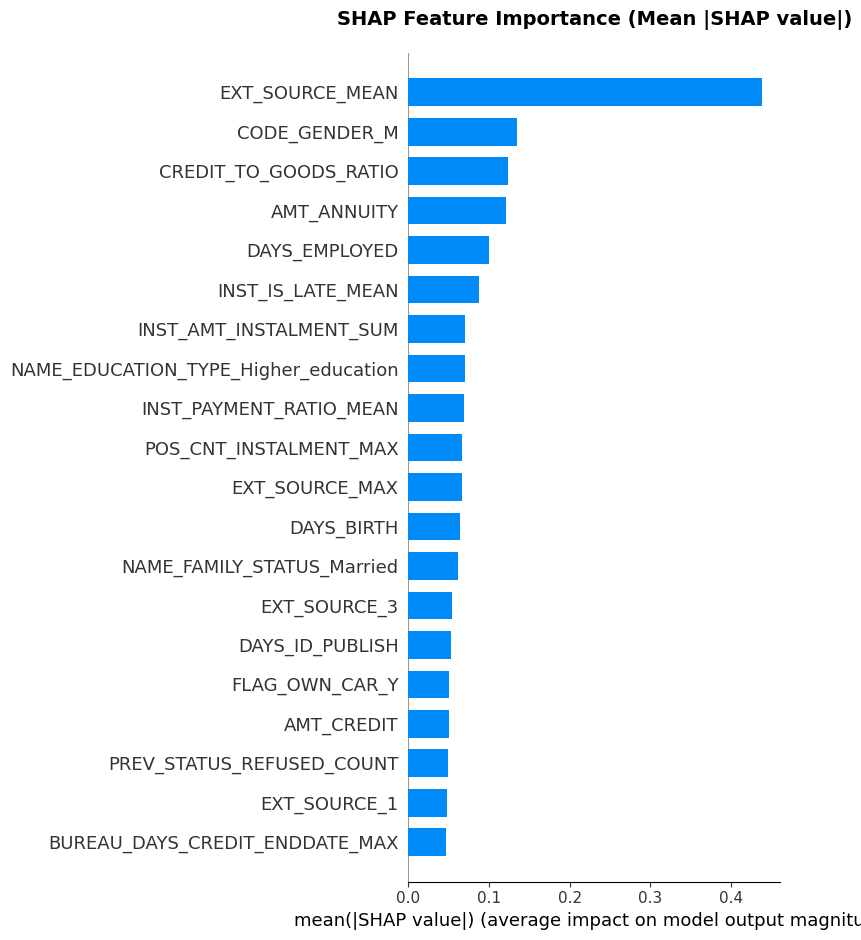

[OK] Bar plot created!


In [8]:
# Bar plot (mean absolute SHAP values)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Bar plot created!")

## 🎯 SHAP Force Plot (Individual Prediction Explanation)

**Force plots explain individual predictions:**
- **Base value:** Average prediction (baseline)
- **Red arrows:** Features pushing prediction HIGHER
- **Blue arrows:** Features pushing prediction LOWER
- **Final prediction:** Where arrows end

**Use Case:** "Why was THIS customer predicted to default?"

Let's explain a few individual predictions!

Explaining highest-risk sample in SHAP subset (original index: 10848)
Predicted probability of default: 0.7239
Actual label: 0


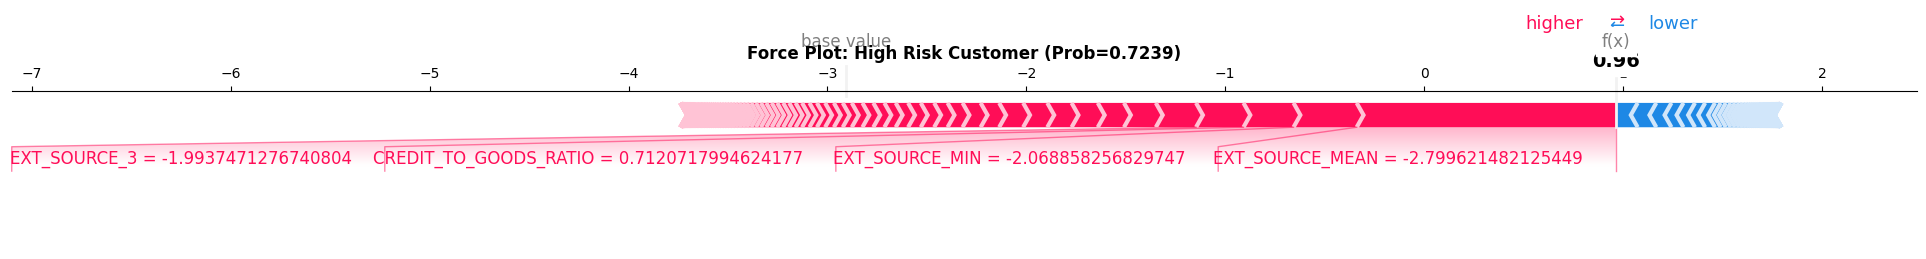


[OK] Force plot created!

Interpretation:
  Base value (expected): -2.9071
  Final prediction:      0.7239
  Red features pushed prediction up (increased risk)
  Blue features pushed prediction down (decreased risk)


In [9]:
# Find the highest-risk observation within the SHAP sample (not the full val set,
# since only the sample has pre-computed SHAP values).
sample_proba = best_model.predict_proba(X_test_sample)[:, 1]
high_risk_pos = int(sample_proba.argmax())        # position within sample array
high_risk_global_idx = X_test_sample.index[high_risk_pos]  # original val-set index

print(f"Explaining highest-risk sample in SHAP subset (original index: {high_risk_global_idx})")
print(f"Predicted probability of default: {sample_proba[high_risk_pos]:.4f}")
print(f"Actual label: {y_test.iloc[high_risk_global_idx]}")

shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_pos, :],
    X_test_sample.iloc[high_risk_pos, :],
    matplotlib=True,
    show=False,
)
plt.title(
    f"Force Plot: High Risk Customer (Prob={sample_proba[high_risk_pos]:.4f})",
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_force_plot_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[OK] Force plot created!")
print(f"\nInterpretation:")
print(f"  Base value (expected): {explainer.expected_value:.4f}")
print(f"  Final prediction:      {sample_proba[high_risk_pos]:.4f}")
print("  Red features pushed prediction up (increased risk)")
print("  Blue features pushed prediction down (decreased risk)")

## 📈 SHAP Dependence Plots

**Dependence plots show:**
- How a single feature affects predictions
- Interaction effects with other features
- Non-linear relationships

**How to Read:**
- X-axis: Feature value
- Y-axis: SHAP value (impact on prediction)
- Color: Interaction feature value

Let's examine the top features!

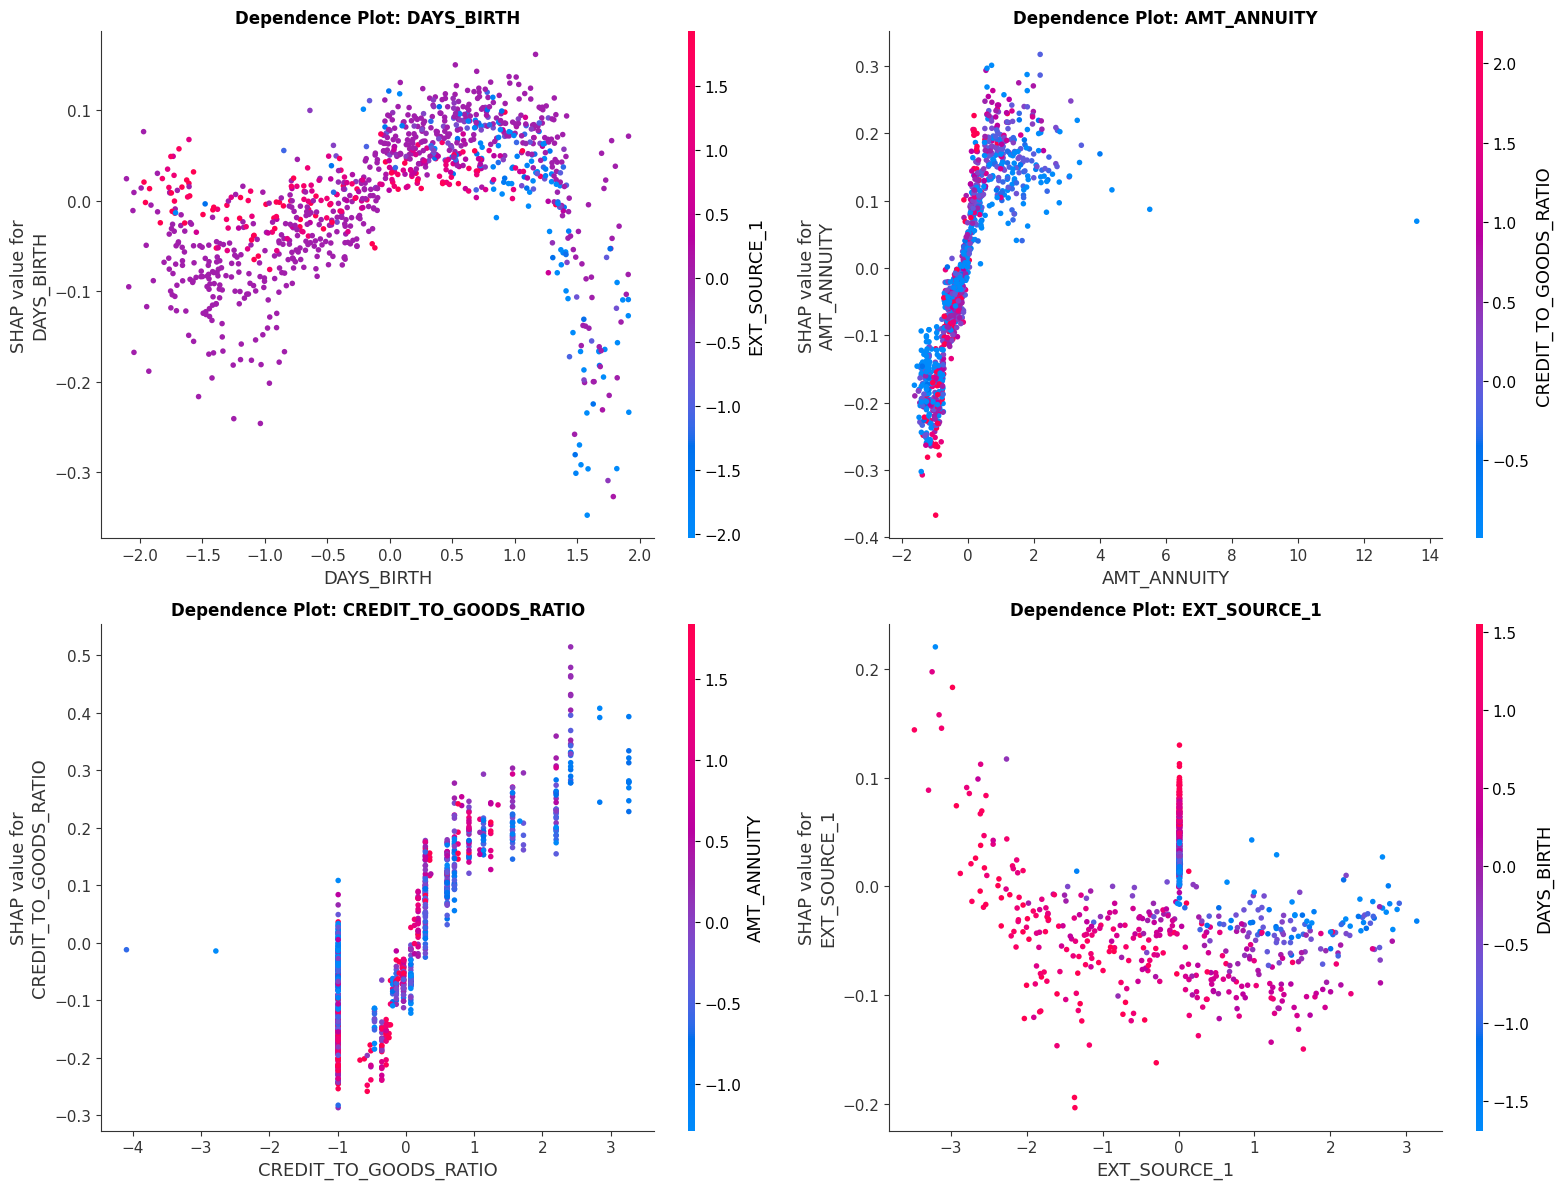

[OK] Dependence plots created!

Key Insights:
- Scatter shows relationship between feature value and impact
- Color shows interaction with other features
- Non-linear patterns visible


In [10]:
# Get top 4 features
top_features = feature_importance_df.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    if feature in X_test_sample.columns:
        feature_idx = X_test_sample.columns.get_loc(feature)

        shap.dependence_plot(
            feature_idx,
            shap_values,
            X_test_sample,
            ax=axes[idx],
            show=False
        )
        axes[idx].set_title(f'Dependence Plot: {feature}',
                           fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Dependence plots created!")
print("\nKey Insights:")
print("- Scatter shows relationship between feature value and impact")
print("- Color shows interaction with other features")
print("- Non-linear patterns visible")

## 💼 Business Insights and Recommendations

Based on our model interpretation, let's generate actionable insights.

In [11]:
# Analyze top features for business insights
print("="*80)
print("BUSINESS INSIGHTS FROM MODEL INTERPRETATION")
print("="*80)

# Top 10 features
top_10_features = feature_importance_df.head(10)

print("\n📊 TOP 10 MOST INFLUENTIAL FACTORS FOR LOAN DEFAULT:")
print("-"*80)

for idx, row in top_10_features.iterrows():
    feature = row['feature']
    importance = row['importance']

    print(f"\n{idx+1}. {feature}")
    print(f"   Importance Score: {importance:.4f}")

    # Add business interpretation (customize based on your features)
    if 'DEBT_TO_INCOME' in feature.upper():
        print("   📍 Insight: High debt relative to income strongly indicates default risk")
        print("   💡 Recommendation: Implement stricter debt-to-income ratio requirements")

    elif 'EXT_SOURCE' in feature.upper():
        print("   📍 Insight: External credit bureau scores are highly predictive")
        print("   💡 Recommendation: Always obtain external credit checks")

    elif 'AGE' in feature.upper():
        print("   📍 Insight: Customer age affects default probability")
        print("   💡 Recommendation: Consider age-based risk tiers")

    elif 'DAYS_EMPLOYED' in feature.upper() or 'EMPLOYMENT' in feature.upper():
        print("   📍 Insight: Employment stability is a key risk indicator")
        print("   💡 Recommendation: Verify employment history thoroughly")

    elif 'INCOME' in feature.upper():
        print("   📍 Insight: Income level and stability matter")
        print("   💡 Recommendation: Require income verification documents")

    elif 'ANNUITY' in feature.upper():
        print("   📍 Insight: Payment burden affects ability to repay")
        print("   💡 Recommendation: Calculate and cap payment-to-income ratio")

print("\n" + "="*80)
print("\n[OK] Business insights generated!")

BUSINESS INSIGHTS FROM MODEL INTERPRETATION

📊 TOP 10 MOST INFLUENTIAL FACTORS FOR LOAN DEFAULT:
--------------------------------------------------------------------------------

5. DAYS_BIRTH
   Importance Score: 146.0000

4. AMT_ANNUITY
   Importance Score: 126.0000
   📍 Insight: Payment burden affects ability to repay
   💡 Recommendation: Calculate and cap payment-to-income ratio

150. CREDIT_TO_GOODS_RATIO
   Importance Score: 121.0000

23. EXT_SOURCE_1
   Importance Score: 113.0000
   📍 Insight: External credit bureau scores are highly predictive
   💡 Recommendation: Always obtain external credit checks

43. BUREAU_DAYS_CREDIT_MAX
   Importance Score: 103.0000

3. AMT_CREDIT
   Importance Score: 99.0000

6. DAYS_EMPLOYED
   Importance Score: 99.0000
   📍 Insight: Employment stability is a key risk indicator
   💡 Recommendation: Verify employment history thoroughly

153. EXT_SOURCE_MEAN
   Importance Score: 98.0000
   📍 Insight: External credit bureau scores are highly predictive
 

## ⚠️ Model Limitations and Considerations

**Important Limitations:**

1. **Training Data Bias**
   - Model learns from historical data
   - If past decisions were biased, model may perpetuate bias
   - Regular audits needed for fairness

2. **Feature Reliability**
   - Self-reported data may be inaccurate
   - External scores may change
   - Economic conditions evolve

3. **Correlation ≠ Causation**
   - High SHAP value doesn't mean causal relationship
   - Be cautious with interpretations
   - Domain expertise still essential

4. **Model Drift**
   - Performance degrades over time
   - Regular retraining required
   - Monitor production predictions

5. **Edge Cases**
   - Unusual applications may be misclassified
   - Model trained on typical cases
   - Human review for outliers recommended

**Recommendations for Production:**
- ✅ Regular model retraining (quarterly)
- ✅ Monitor prediction distributions
- ✅ A/B testing before full deployment
- ✅ Human review for high-risk decisions
- ✅ Fairness audits across demographics
- ✅ Explainability for customer disputes
- ✅ Documentation of model limitations

## 📝 Project Summary and Conclusion

### ✅ Complete ML Pipeline Accomplished

**Phase 1: Exploratory Data Analysis**
- ✓ Analyzed 307K loan applications
- ✓ Identified class imbalance (~8% defaults)
- ✓ Assessed missing values and data quality
- ✓ Explored feature distributions and correlations

**Phase 2: Feature Engineering**
- ✓ Created 10+ domain-based features
- ✓ Handled missing values (fit on training set only — no leakage)
- ✓ Encoded categorical variables
- ✓ Scaled numerical features
- ✓ Selected most relevant features (variance threshold + correlation filter)

**Phase 3: Baseline Model Training**
- ✓ Trained 5 models: Dummy, Logistic Regression, Random Forest, XGBoost, LightGBM
- ✓ Logged all experiments with MLflow
- ✓ Evaluated using ROC-AUC and PR-AUC (appropriate for imbalanced data)
- ✓ Selected best baseline: LightGBM

**Phase 4: Hyperparameter Optimization**
- ✓ Random Search: 10 iterations × 5-fold stratified CV on 20% subsample = 50 fits
- ✓ Best configuration retrained on full dataset
- ✓ Optimized for ROC-AUC
- ✓ All runs tracked in MLflow
- ✓ Best model saved with timestamp for reproducibility

**Phase 5: Model Interpretation**
- ✓ LightGBM built-in feature importance
- ✓ SHAP TreeExplainer — global summary and bar plots
- ✓ SHAP force plot for highest-risk individual prediction
- ✓ SHAP dependence plots for top 4 features
- ✓ Business insights generated from feature drivers

### 🏆 Final Model Performance

**Key Metrics (on validation set):**
- **ROC-AUC:** Check evaluation output above
- **PR-AUC:** Check evaluation output above
- **F1-Score:** Check evaluation output above

### 💡 Key Learnings

1. **Class Imbalance is Critical**
   - Accuracy is a misleading metric (~92% accuracy by always predicting "no default")
   - ROC-AUC and PR-AUC are the appropriate metrics
   - `class_weight='balanced'` handles imbalance during training

2. **Feature Engineering Matters**
   - Domain features (debt ratios, income per person) drive the most gain
   - External credit bureau scores (`EXT_SOURCE_*`) are the most predictive raw features
   - Good features > complex models

3. **Reproducibility Requires Discipline**
   - Seed `random`, `numpy`, and the model's `random_state`
   - Use `n_jobs=1` for tree models (parallel building is non-deterministic)
   - Shuffle concatenated datasets before cross-validation
   - Fit transformers only on the training split

4. **Interpretability is Essential**
   - SHAP provides consistent, theoretically-grounded explanations
   - TreeExplainer is exact (no approximation) for tree ensembles
   - Force plots answer "why did THIS customer get this score?"

### 🎯 Production Recommendations

**Before Deployment:**
1. ✅ Validate on fresh data from a later time period (temporal validation)
2. ✅ Set prediction threshold based on business cost of FP vs FN
3. ✅ Create monitoring dashboards (feature drift, score distribution)
4. ✅ Document model card for compliance (GDPR, Fair Credit)
5. ✅ Plan quarterly retraining schedule

**Cost-Benefit Analysis:**
- False Positive (predict default, client repays): Lost business opportunity
- False Negative (predict repayment, client defaults): Bad loan loss
- Optimize threshold based on actual loss amounts

### 🎓 Project Complete

You've implemented a full end-to-end credit scoring pipeline:
- ✅ From raw data to an interpretable, optimized model
- ✅ Professional MLOps practices with MLflow experiment tracking
- ✅ Reproducible pipeline with seeded RNGs and leakage-free preprocessing
- ✅ SHAP-based interpretability for regulatory compliance

---

**Project by:** Shahul SHAIK  
**Date:** May 2026  
**Framework:** Scikit-learn, LightGBM, MLflow, SHAP  
**Dataset:** Home Credit Default Risk (Kaggle)

---

For questions or improvements, refer to the project documentation.